# connect kaggle

In [ ]:
!pip install -q kaggle

# declare token
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_a08f9b6b9025401467ead523f76d243c"

# down data
!kaggle datasets download -d faldoae/padangfood

!unzip -q padangfood.zip -d padang_dataset
print("finish")

Dataset URL: https://www.kaggle.com/datasets/faldoae/padangfood
License(s): ODbL-1.0
100% 114M/114M [00:08<00:00, 14.6MB/s]

finish


#Load & Inspect Data



In [ ]:
import pandas as pd
from pathlib import Path

data_dir = 'padang_dataset/dataset_padang_food'
paths, labels = [], []

print("Scanning folder...")
for path in Path(data_dir).rglob('*.*'):
    if path.is_file():
        paths.append(str(path))
        labels.append(path.parent.name)

df = pd.DataFrame({'path': paths, 'species': labels})
df = df.sort_values('species').reset_index(drop=True)

print("="*41)
print(f"Successful")
print(f"Total img: {len(df)}")
print(f"Classes: {df['species'].nunique()}")
print("="*41)
display(df.head())

Scanning folder...
Successful
Total img: 993
Classes: 9


,path,species
0,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
1,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
2,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
3,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
4,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng


# Feature Extraction

In [ ]:
import cv2
import numpy as np
import os
from tqdm.notebook import tqdm

# Initialize lists to store parameters
widths, heights, aspect_ratios, file_sizes = [], [], [], []
mean_r, mean_g, mean_b = [], [], []
brightness, contrast, sharpness = [], [], []

print("starting scan img...")

# loop img in dataframe
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    img_path = row['path']

    # check file size
    file_sizes.append(os.path.getsize(img_path) / 1024.0)

    img = cv2.imread(img_path)

    if img is not None:
        # Size
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h if h != 0 else 0)

        # Color
        # OpenCV read img using the BGR color system, then -> RGB.
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_r.append(img_rgb[:, :, 0].mean())
        mean_g.append(img_rgb[:, :, 1].mean())
        mean_b.append(img_rgb[:, :, 2].mean())

        # Quality Metrics
        # Convert img to black, white -> brightness, contrast, and sharpness
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(gray.mean())               # Mean
        contrast.append(gray.std())                  # Standard deviation
        sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var()) # sharp
    else:
        # if error -> none
        widths.append(None); heights.append(None); aspect_ratios.append(None)
        mean_r.append(None); mean_g.append(None); mean_b.append(None)
        brightness.append(None); contrast.append(None); sharpness.append(None)

# push paramto to dataframe
df['width'] = widths
df['height'] = heights
df['aspect_ratio'] = aspect_ratios
df['file_size_kb'] = file_sizes
df['mean_r'] = mean_r
df['mean_g'] = mean_g
df['mean_b'] = mean_b
df['brightness'] = brightness
df['contrast'] = contrast
df['sharpness'] = sharpness

# delete img error
df = df.dropna().reset_index(drop=True)

print("\nFinish")
print("Display:")
display(df.head())

starting scan img...


  0%|          | 0/993 [00:00<?, ?it/s]


Finish
Display:


,path,species,width,height,aspect_ratio,file_size_kb,mean_r,mean_g,mean_b,brightness,contrast,sharpness
0,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,713,557,1.280072,120.702148,153.212499,116.716569,80.399546,123.494462,52.592461,404.589517
1,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,931,565,1.647788,130.739258,121.787396,84.510204,57.236039,92.558146,58.966362,169.378316
2,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,1600,1066,1.500938,240.187500,164.073100,108.188224,75.781639,121.215315,60.505492,474.774439
3,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,972,630,1.542857,179.908203,148.934382,99.998623,53.066529,109.288766,45.174937,135.412283
4,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,968,570,1.698246,186.393555,140.047671,133.044184,67.667683,127.691513,49.871351,1250.450620


#Visualizations

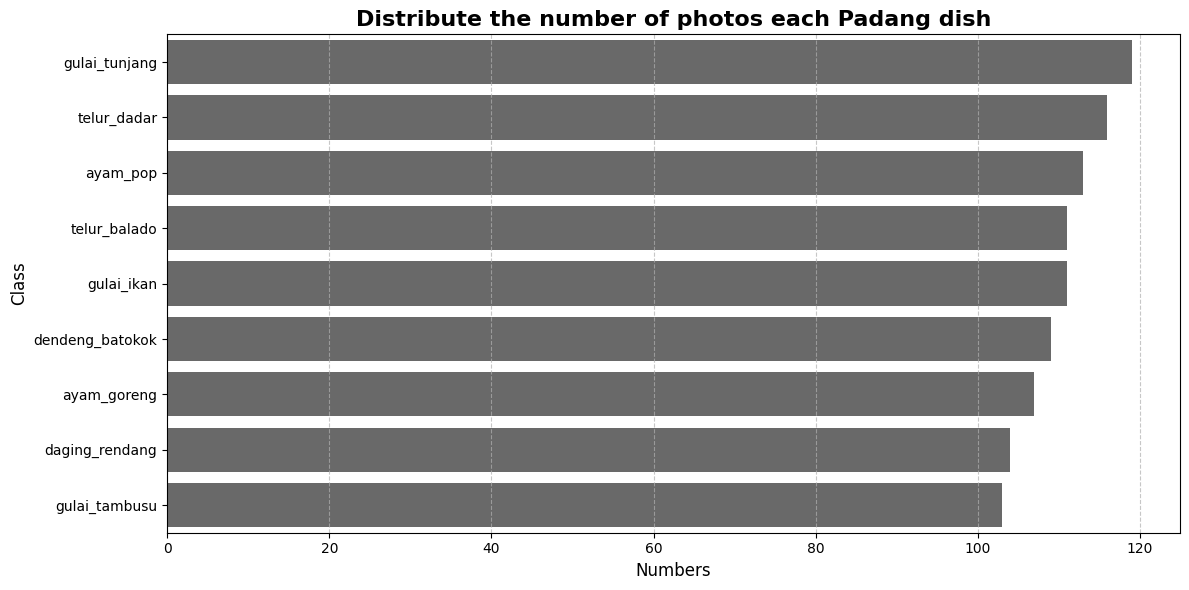

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='species', order=df['species'].value_counts().index, color='dimgray')

plt.title('Distribute the number of photos each Padang dish', fontsize=16, fontweight='bold')
plt.xlabel('Numbers', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import cv2

# list class
classes = sorted(df['species'].unique().tolist())

# scrool menu
dropdown = widgets.Dropdown(
    options=classes,
    value=classes[0],
    description='choose:',
    style={'description_width': 'initial'}
)
output = widgets.Output()

# change img when choose another class
def update_gallery(change):
    with output:
        clear_output(wait=True)
        selected_class = change.new

        # select random img in class
        class_df = df[df['species'] == selected_class]
        sample_imgs = class_df.sample(min(4, len(class_df))).reset_index(drop=True)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f"img: {selected_class.upper().replace('_', ' ')}", fontsize=16, fontweight='bold', y=1.05)

        for i in range(4):
            if i < len(sample_imgs):
                # Read, display img
                img = cv2.imread(sample_imgs.loc[i, 'path'])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
                axes[i].axis('off')
                axes[i].set_title(f"Size: {img.shape[1]}x{img.shape[0]}")
            else:
                axes[i].axis('off')

        plt.tight_layout()
        plt.show()

dropdown.observe(update_gallery, names='value')
display(dropdown, output)
dropdown.value = classes[1]
dropdown.value = classes[0]

Dropdown(description='choose:', options=('ayam_goreng', 'ayam_pop', 'daging_rendang', 'dendeng_batokok', 'gula…

Output()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

print("="*70)
print("📊 FINAL CORE EDA - Padang Cuisine Image Dataset (Plotly)")
print("="*70)

# Automatically generate a color palette for the 9 Padang cuisine classes
species_list = df['species'].unique()
palette = px.colors.qualitative.Prism
colors = {species: palette[i % len(palette)] for i, species in enumerate(species_list)}

# Common legend layout to avoid overlapping with titles
legend_layout = dict(
    orientation="h",
    yanchor="top",
    y=-0.2,
    xanchor="center",
    x=0.5
)
common_margin = dict(t=60, b=80, l=50, r=50)


# 1: Image Quality Metrics (Sharpness vs Contrast)

print("\n1️⃣ Creating Image Quality Metrics chart...")
fig1 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig1.add_trace(go.Scatter(
        x=species_data['sharpness'],
        y=species_data['contrast'],
        mode='markers',
        name=species.replace('_', ' ').title(),
        marker=dict(color=colors[species], size=7, opacity=0.7, line=dict(width=0.5, color='white')),
        text=species_data['path'].apply(lambda x: x.split('/')[-1]), # Extract filename for hover
        hovertemplate='<b>%{text}</b><br>Sharpness: %{x:.1f}<br>Contrast: %{y:.1f}<extra></extra>'
    ))

fig1.update_layout(
    title="Image Quality Metrics (Sharpness vs Contrast)",
    xaxis=dict(title="Sharpness (Laplacian Variance)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Contrast (Standard Deviation)", showgrid=True, gridcolor="#f0f0f0"),
    width=900, height=550, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig1.show()


# 2: RGB Color Space Distribution (3D Cube)
print("\n2️⃣ Creating 3D RGB Color Space chart...")
fig2 = go.Figure(data=[go.Scatter3d(
    x=df['mean_r'],
    y=df['mean_g'],
    z=df['mean_b'],
    mode='markers',
    marker=dict(
        size=4,
        color=df['brightness'],  # Color based on brightness
        colorscale='Viridis',
        opacity=0.7,
        colorbar=dict(title="Brightness", thickness=15, len=0.7, x=1.05)
    ),
    text=df['species'] + '<br>' + df['path'].apply(lambda x: x.split('/')[-1]),
    hovertemplate='<b>%{text}</b><br>Red: %{x:.1f}<br>Green: %{y:.1f}<br>Blue: %{z:.1f}<br>Brightness: %{marker.color:.1f}<extra></extra>'
)])

fig2.update_layout(
    title="RGB Color Space Distribution (3D Cube)",
    scene=dict(
        xaxis=dict(title='Red Channel', range=[0, 255]),
        yaxis=dict(title='Green Channel', range=[0, 255]),
        zaxis=dict(title='Blue Channel', range=[0, 255]),
        bgcolor='rgba(250, 250, 250, 0.9)'
    ),
    width=900, height=600, showlegend=False,
    margin=dict(t=60, b=20, l=20, r=20)
)
fig2.show()

# 3: Size Marginal Distribution (Width vs Height)
print("\nCreating Size Marginal Distribution chart...")
fig3 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig3.add_trace(go.Scatter(
        x=species_data['width'],
        y=species_data['height'],
        mode='markers',
        name=species.replace('_', ' ').title(),
        marker=dict(color=colors[species], size=6, opacity=0.7, line=dict(width=0.5, color='white')),
        text=species_data['path'].apply(lambda x: x.split('/')[-1]),
        hovertemplate='<b>%{text}</b><br>Width: %{x} px<br>Height: %{y} px<extra></extra>'
    ))

fig3.update_layout(
    title="Size Marginal Distribution (Width x Height)",
    xaxis=dict(title="Width (pixels)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Height (pixels)", showgrid=True, gridcolor="#f0f0f0"),
    width=900, height=550, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig3.show()

# 4: File Size Distribution
print("\nCreating File Size Distribution chart...")
fig4 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig4.add_trace(go.Histogram(
        x=species_data['file_size_kb'],
        name=species.replace('_', ' ').title(),
        opacity=0.7,
        marker_color=colors[species],
        nbinsx=40
    ))

fig4.update_layout(
    title="File Size Distribution",
    xaxis=dict(title="File Size (KB)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Count", showgrid=True, gridcolor="#f0f0f0"),
    barmode="overlay", # Overlapping histograms for comparison
    width=900, height=500, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig4.show()

# 5: Aspect Ratio Distribution
print("\nCreating Aspect Ratio Distribution chart...")
fig5 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig5.add_trace(go.Histogram(
        x=species_data['aspect_ratio'],
        name=species.replace('_', ' ').title(),
        opacity=0.7,
        marker_color=colors[species],
        nbinsx=40
    ))

# Add vertical lines for common aspect ratios
common_ratios = [0.75, 1.0, 1.33, 1.5, 1.77]
ratio_names = ['3:4 (Tall)', '1:1 (Square)', '4:3 (Wide)', '3:2', '16:9']
shapes = []
annotations = []

for ratio, name in zip(common_ratios, ratio_names):
    shapes.append(dict(type="line", x0=ratio, y0=0, x1=ratio, y1=1, yref="paper", line=dict(color="red", width=1.5, dash="dash")))
    annotations.append(dict(x=ratio, y=1, yref="paper", text=name, showarrow=False, yanchor="bottom", font=dict(size=10, color="red")))

fig5.update_layout(
    title="Aspect Ratio Distribution",
    xaxis=dict(title="Aspect Ratio (Width/Height)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Count", showgrid=True, gridcolor="#f0f0f0"),
    barmode="overlay",
    width=900, height=500, template="plotly_white",
    shapes=shapes, annotations=annotations,
    legend=legend_layout,
    margin=common_margin
)
fig5.show()

# ============================================================================
# STATISTICS SUMMARY
# ============================================================================
print("\n" + "="*70)
print("FINAL STATISTICS SUMMARY")
print("="*70)
print(f"Total Images: {len(df):,} images\n")

print(f"Dimensions:")
print(f"   • Mean width : {df['width'].mean():.1f} px (std: {df['width'].std():.1f})")
print(f"   • Mean height: {df['height'].mean():.1f} px (std: {df['height'].std():.1f})")
print(f"   • Min size   : {df['width'].min()} x {df['height'].min()} px")
print(f"   • Max size   : {df['width'].max()} x {df['height'].max()} px\n")

print(f"File Sizes:")
print(f"   • Mean   : {df['file_size_kb'].mean():.1f} KB")
print(f"   • Median : {df['file_size_kb'].median():.1f} KB")
print(f"   • Total  : {df['file_size_kb'].sum()/1024:.1f} MB\n")

print(f"Aspect Ratios:")
print(f"   • Mean   : {df['aspect_ratio'].mean():.2f}")
print(f"   • Median : {df['aspect_ratio'].median():.2f}")
print(f"   • Range  : {df['aspect_ratio'].min():.2f} - {df['aspect_ratio'].max():.2f}\n")

print(f"RGB Color Averages:")
print(f"   • Red   : {df['mean_r'].mean():.1f}")
print(f"   • Green : {df['mean_g'].mean():.1f}")
print(f"   • Blue  : {df['mean_b'].mean():.1f}")
print("="*70)
print("✅ EDA Complete! All required charts generated.")

📊 FINAL CORE EDA - Padang Cuisine Image Dataset (Plotly)

1️⃣ Creating Image Quality Metrics chart...



2️⃣ Creating 3D RGB Color Space chart...



Creating Size Marginal Distribution chart...



Creating File Size Distribution chart...



Creating Aspect Ratio Distribution chart...



FINAL STATISTICS SUMMARY
Total Images: 993 images

Dimensions:
   • Mean width : 730.1 px (std: 348.0)
   • Mean height: 518.4 px (std: 245.4)
   • Min size   : 72 x 72 px
   • Max size   : 2810 x 2188 px

File Sizes:
   • Mean   : 119.2 KB
   • Median : 68.2 KB
   • Total  : 115.6 MB

Aspect Ratios:
   • Mean   : 1.43
   • Median : 1.41
   • Range  : 0.56 - 3.33

RGB Color Averages:
   • Red   : 157.8
   • Green : 119.8
   • Blue  : 79.7
✅ EDA Complete! All required charts generated.


#PART 2: ASSIGNMENT 2 (MACHINE LEARNING & TRANSFER LEARNING)

#Thiết lập AI, Lọc dữ liệu & Chia tập (Kế thừa DataFrame từ EDA)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*70)
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    print(f"connect successfull: {gpu_name}")
else:
    print(f"connect successfull: {device.type.upper()}")
print("="*70)

print("\n🧹 Filtering small artifacts (size < 15KB)...")
df_ml = df[df['file_size_kb'] >= 15.0].reset_index(drop=True)
print(f"   ✓ Remaining images: {len(df_ml)}")

# 2. Encode Labels
class_names = sorted(df_ml['species'].unique())
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
df_ml['label'] = df_ml['species'].map(class_to_idx)

# 3. Stratified Split (Train 70%, Val 15%, Test 15%)
print("\n🔀 Splitting data (Train/Val/Test)...")
train_df, temp_df = train_test_split(df_ml, test_size=0.3, stratify=df_ml['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# Reset index
train_df, val_df, test_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)
print(f"   ✓ Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

connect successfull: Tesla T4

🧹 Filtering small artifacts (size < 15KB)...
   ✓ Remaining images: 965

🔀 Splitting data (Train/Val/Test)...
   ✓ Train: 675 | Val: 145 | Test: 145


#Biểu đồ phân phối Train/Val/Test

In [ ]:
print("\nCreating Split Distribution Chart...")
split_colors = {'Train': '#3b82f6', 'Validation': '#10b981', 'Test': '#f59e0b'}
split_data = []

for split_name, split_df in zip(['Train', 'Validation', 'Test'], [train_df, val_df, test_df]):
    counts = split_df['species'].value_counts().to_dict()
    for species in class_names:
        split_data.append({
            'Species': species.replace('_', ' ').title(),
            'Split': split_name,
            'Count': counts.get(species, 0)
        })

split_df_chart = pd.DataFrame(split_data)
fig_split = go.Figure()

for split_name in ['Train', 'Validation', 'Test']:
    subset = split_df_chart[split_df_chart['Split'] == split_name]
    fig_split.add_trace(go.Bar(
        x=subset['Species'], y=subset['Count'],
        name=split_name, marker_color=split_colors[split_name]
    ))

fig_split.update_layout(
    title="Train/Val/Test Split Distribution",
    xaxis_title="Padang Cuisine Classes", yaxis_title="Number of Images",
    barmode='group', template="plotly_white", height=450,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig_split.show()


Creating Split Distribution Chart...


#Định nghĩa Dataset & DataLoader (Data Augmentation)

In [ ]:
class PadangDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'path']
        label = self.dataframe.loc[idx, 'label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# ImageNet Norm params
mean_imagenet, std_imagenet = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Augmentation cho Train
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_imagenet, std=std_imagenet)
])

# Transforms cơ bản cho Val/Test
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_imagenet, std=std_imagenet)
])

batch_size = 16
train_loader = DataLoader(PadangDataset(train_df, train_transform), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(PadangDataset(val_df, val_test_transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(PadangDataset(test_df, val_test_transform), batch_size=batch_size, shuffle=False)

#Khởi tạo ResNet50 & Vòng lặp Huấn luyện

In [ ]:
print("Setting up EfficientNet-B0 for Transfer Learning")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# 1. Freeze initial feature blocks
for param in model.parameters():
    param.requires_grad = False

# 2. Unfreeze the last feature block for deeper fine-tuning
for param in model.features[-1].parameters():
    param.requires_grad = True

# 3. Replace the final classifier
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)
criterion = nn.CrossEntropyLoss()

# Optimize only the unfreezed layers
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

num_epochs = 30
best_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"\nStarting Training with {num_epochs} Epochs...")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    model.eval()
    val_loss, corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_df)
    epoch_val_loss = val_loss / len(val_df)
    epoch_val_acc = corrects.double() / len(val_df)

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())

    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_efficientnet_b0.pth')

print(f"\nTraining Complete! Best Validation Accuracy: {best_acc:.4f}")

Setting up EfficientNet-B0 for Transfer Learning
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]



Starting Training with 30 Epochs...


Epoch 1/30 [Train]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 2.1344 | Val Loss: 1.9927 | Val Acc: 0.3931


...

Epoch 28 | Train Loss: 0.3248 | Val Loss: 0.4455 | Val Acc: 0.8966


Epoch 29/30 [Train]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 29 | Train Loss: 0.3487 | Val Loss: 0.4353 | Val Acc: 0.8759


Epoch 30/30 [Train]:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 30 | Train Loss: 0.3280 | Val Loss: 0.4174 | Val Acc: 0.9103

Training Complete! Best Validation Accuracy: 0.9103


#Learning Curves Visualization

Plotting Learning Curves...


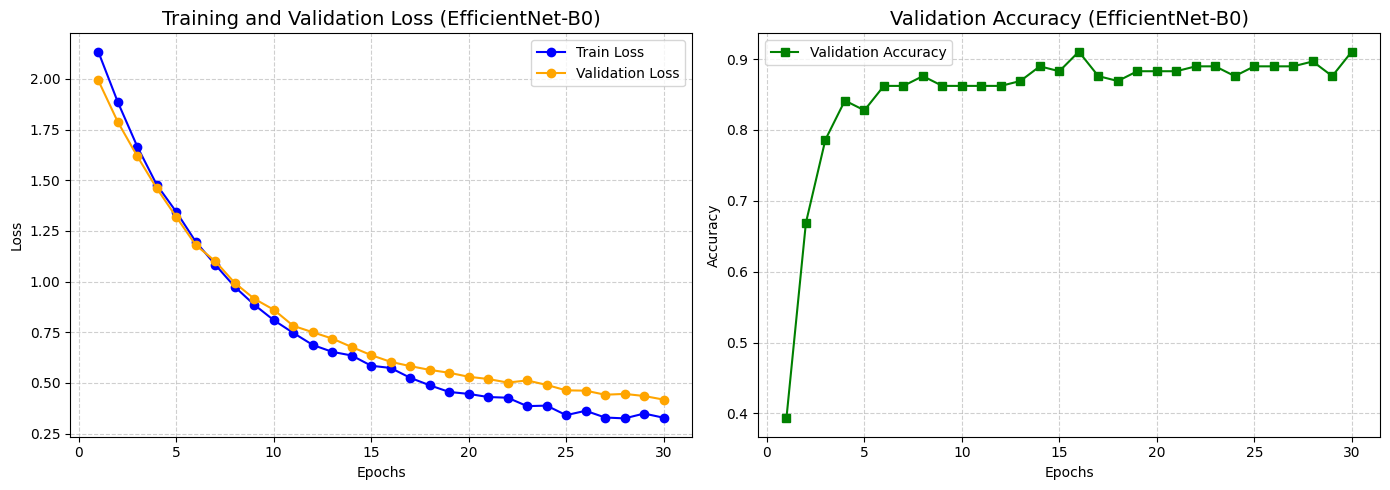

In [ ]:
print("Plotting Learning Curves...")

epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(14, 5))

# Chart 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Training and Validation Loss (EfficientNet-B0)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Chart 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='green', marker='s')
plt.title('Validation Accuracy (EfficientNet-B0)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#Evaluation (Report & Confusion Matrix)


TEST SET CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    ayam_goreng       0.92      0.69      0.79        16
       ayam_pop       0.74      1.00      0.85        17
 daging_rendang       0.93      0.87      0.90        15
dendeng_batokok       0.94      1.00      0.97        16
     gulai_ikan       0.80      0.75      0.77        16
  gulai_tambusu       1.00      0.60      0.75        15
  gulai_tunjang       0.82      0.82      0.82        17
   telur_balado       0.83      0.94      0.88        16
    telur_dadar       0.85      1.00      0.92        17

       accuracy                           0.86       145
      macro avg       0.87      0.85      0.85       145
   weighted avg       0.87      0.86      0.85       145



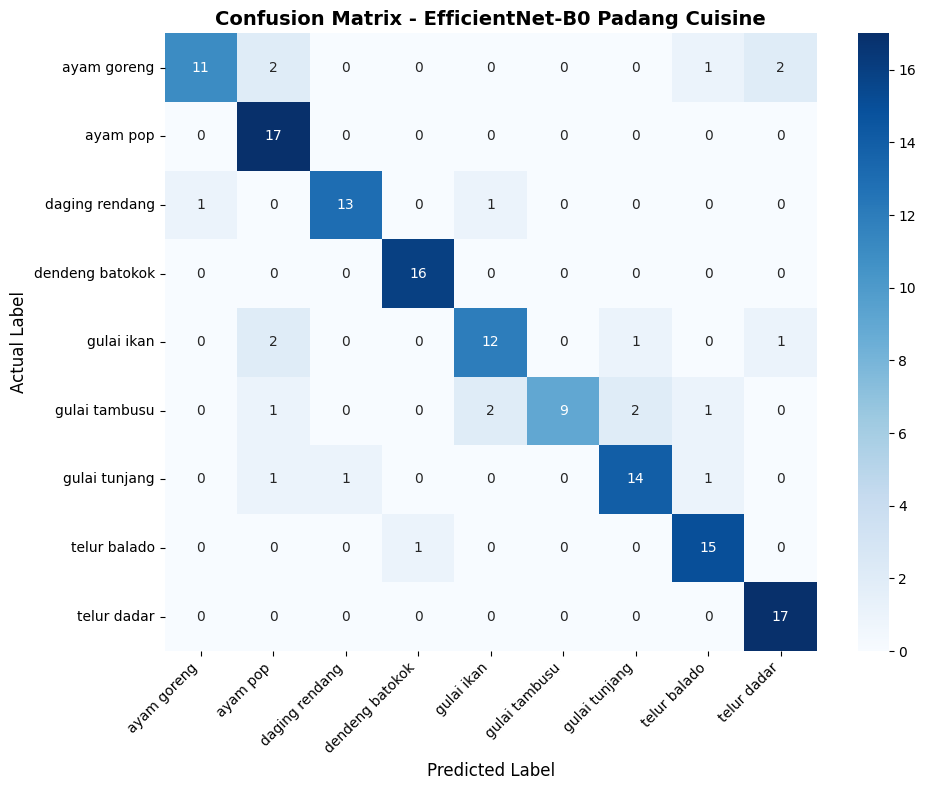

In [ ]:
model.load_state_dict(torch.load('best_efficientnet_b0.pth'))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n" + "="*50)
print("TEST SET CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[n.replace('_', ' ') for n in class_names],
            yticklabels=[n.replace('_', ' ') for n in class_names])
plt.title('Confusion Matrix - EfficientNet-B0 Padang Cuisine', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Advanced Feature Visualization (t-SNE & Heatmap)

Extracting 1280D features from EfficientNet-B0...


Extracting Features:   0%|          | 0/10 [00:00<?, ?it/s]


Running t-SNE 2D Projection...


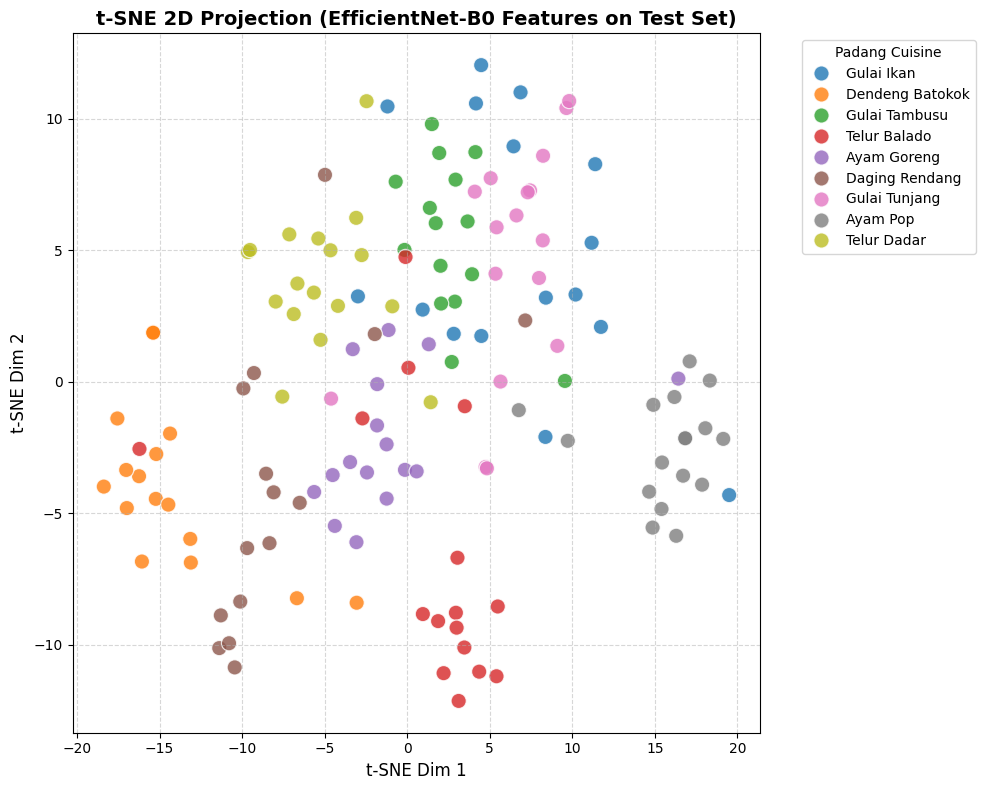


Computing Feature Similarity Heatmap...


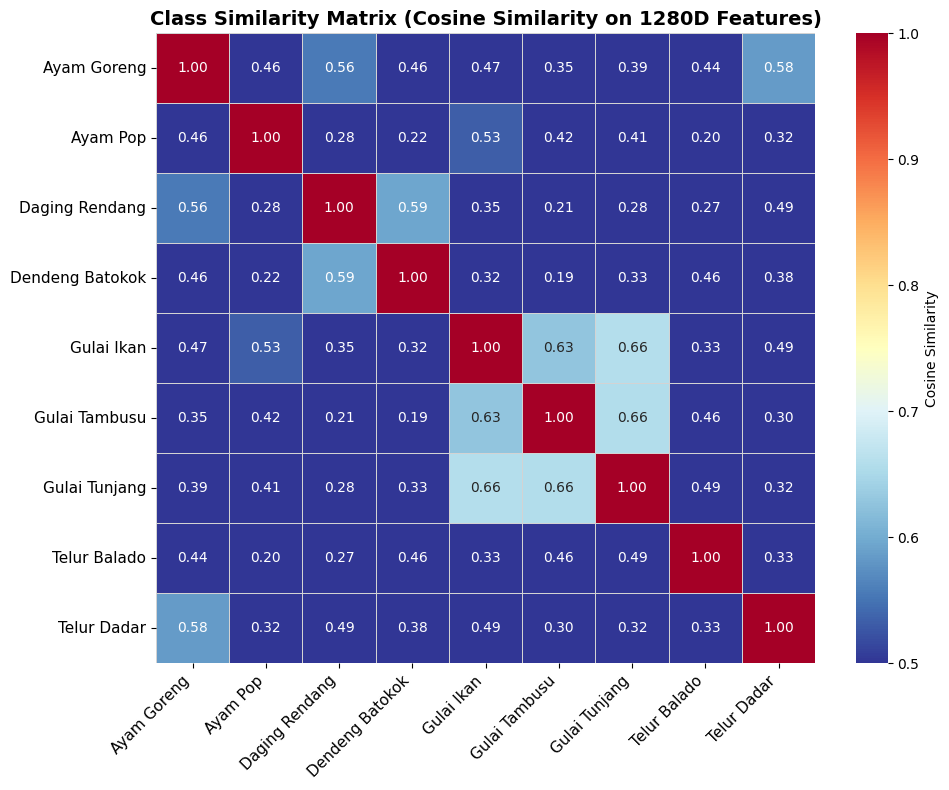

In [ ]:
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Extracting 1280D features from EfficientNet-B0...")

# 1. Trích xuất đặc trưng (Dùng tập Test để đánh giá sự tổng quát hóa)
feature_extractor = nn.Sequential(*list(model.children())[:-1], nn.AdaptiveAvgPool2d(1), nn.Flatten())
feature_extractor.eval()

features_list, labels_list = [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Extracting Features"):
        features = feature_extractor(inputs.to(device)).cpu().numpy()
        features_list.extend(features)
        labels_list.extend(labels.numpy())

features_array = np.array(features_list)
formatted_names = [name.replace('_', ' ').title() for name in class_names]
species_labels = [formatted_names[lbl] for lbl in labels_list]

# ====================================================================
# 2. VẼ BIỂU ĐỒ t-SNE (Matplotlib/Seaborn)
# ====================================================================
print("\nRunning t-SNE 2D Projection...")
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
tsne_results = tsne.fit_transform(features_array)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_results[:, 0], y=tsne_results[:, 1],
    hue=species_labels,
    palette=sns.color_palette("tab10", len(class_names)), # Bộ màu 10 màu rõ nét
    s=120, alpha=0.8, edgecolor='white'
)
plt.title("t-SNE 2D Projection (EfficientNet-B0 Features on Test Set)", fontsize=14, fontweight='bold')
plt.xlabel("t-SNE Dim 1", fontsize=12)
plt.ylabel("t-SNE Dim 2", fontsize=12)
plt.legend(title="Padang Cuisine", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ====================================================================
# 3. VẼ SIMILARITY HEATMAP (Matplotlib/Seaborn)
# ====================================================================
print("\nComputing Feature Similarity Heatmap...")
mean_features = np.array([features_array[np.array(labels_list) == i].mean(axis=0) for i in range(len(class_names))])
sim_matrix = cosine_similarity(mean_features)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", vmin=0.5, vmax=1.0,
    xticklabels=formatted_names, yticklabels=formatted_names,
    linewidths=0.5, linecolor='lightgray', cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('Class Similarity Matrix (Cosine Similarity on 1280D Features)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

#So sánh với Traditional ML

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

print("="*70)
print("COMPARING DEEP LEARNING VS TRADITIONAL ML (SVM)")
print("="*70)

# 1. Extract features for the Training Set (to train the SVM)
print("Extracting features for Training Set...")
train_features_list, train_labels_list = [], []
with torch.no_grad():
    for inputs, labels in tqdm(train_loader, desc="Train Features", leave=False):
        features = feature_extractor(inputs.to(device)).cpu().numpy()
        train_features_list.extend(features)
        train_labels_list.extend(labels.numpy())

X_train_svm = np.array(train_features_list)
y_train_svm = np.array(train_labels_list)

# 2. X_test and y_test are already available from Cell 12
X_test_svm = features_array
y_test_svm = np.array(labels_list)

# 3. Train the Support Vector Machine (SVM) model
print("Training Traditional Machine Learning (SVM) on Extracted Features...")
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

# 4. Evaluate the SVM model
svm_preds = svm_model.predict(X_test_svm)
svm_acc = accuracy_score(y_test_svm, svm_preds)

print("\nFINAL RESULTS COMPARISON:")
print(f"   - Deep Learning (EfficientNet-B0 Fine-tuned): {best_acc:.4f}")
print(f"   - Traditional ML (EfficientNet-B0 Features + Linear SVM): {svm_acc:.4f}")
print("="*70)

COMPARING DEEP LEARNING VS TRADITIONAL ML (SVM)
Extracting features for Training Set...


Train Features:   0%|          | 0/43 [00:00<?, ?it/s]

Training Traditional Machine Learning (SVM) on Extracted Features...

FINAL RESULTS COMPARISON:
   - Deep Learning (EfficientNet-B0 Fine-tuned): 0.9103
   - Traditional ML (EfficientNet-B0 Features + Linear SVM): 0.8759


#Demonstrating Model Inference

DEMONSTRATING MODEL INFERENCE ON TEST SET...


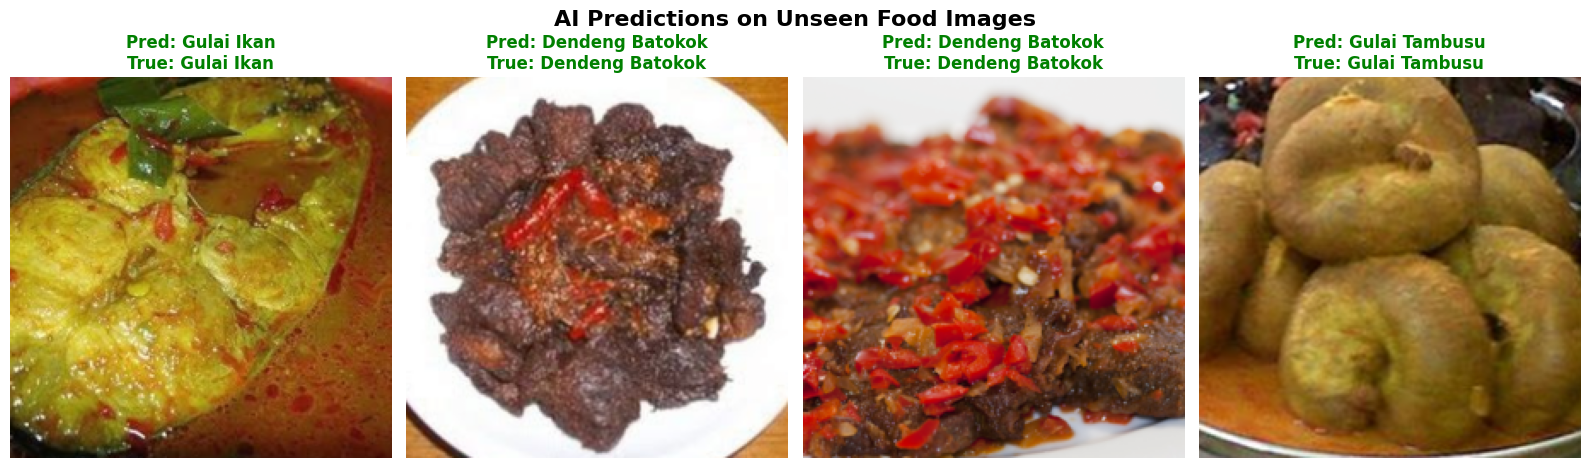

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("DEMONSTRATING MODEL INFERENCE ON TEST SET...")

# Get a random batch of images from the Test set
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

# Perform predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

# Select the first 4 images to display
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('AI Predictions on Unseen Food Images', fontsize=16, fontweight='bold')

# Revert the Normalization process to display colors correctly
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean_imagenet, std_imagenet)],
    std=[1/s for s in std_imagenet]
)

for i in range(4):
    img = inv_normalize(images[i])
    img = np.clip(img.numpy().transpose((1, 2, 0)), 0, 1) # Convert from (C, H, W) to (H, W, C)

    true_label = class_names[labels[i]].replace('_', ' ').title()
    pred_label = class_names[predicted[i]].replace('_', ' ').title()

    color = 'green' if true_label == pred_label else 'red'

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()